In [2]:
import pandas as pd
import numpy as np
import seaborn as snsw
import matplotlib.pyplot as plt
import warnings
import time
warnings.filterwarnings("ignore")


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

In [4]:

df_final = pd.read_csv(r"C:\Users\pc\Desktop\project\tutorial_rdkit\models_prediction_solubulity\delaney_mordred_truncated.csv")

df_final.head()

,Compound ID,SMILES,measured log(solubility:mol/L),ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,...,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
0,"1,1,1,2-Tetrachloroethane",ClCC(Cl)(Cl)Cl,-2.18,4.012290,0,0.969771,11.637367,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
1,"1,1,1-Trichloroethane",CC(Cl)(Cl)Cl,-2.00,3.464102,0,0.800000,8.000000,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
2,"1,1,2,2-Tetrachloroethane",ClC(Cl)C(Cl)Cl,-1.74,3.932653,0,1.000000,11.530010,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
3,"1,1,2-Trichloroethane",ClCC(Cl)Cl,-1.48,3.047207,0,1.045250,8.629874,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
4,"1,1,2-Trichlorotrifluoroethane",FC(F)(Cl)C(F)(Cl)Cl,-3.04,5.808525,0,0.901388,17.881697,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0


In [5]:
y = df_final['measured log(solubility:mol/L)']
X = pd.DataFrame(StandardScaler().fit_transform(df_final.iloc[:, 3:]), columns = df_final.iloc[:, 3:].columns)

                  
X.shape


(1144, 283)

In [6]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
print(f'The r2 score for train set is : {rf.score(X_train, y_train)}')
print(f'The r2 score for test set is : {rf.score(X_test, y_test)}')


The r2 score for train set is : 0.9830439523797581
The r2 score for test set is : 0.8951641706803852


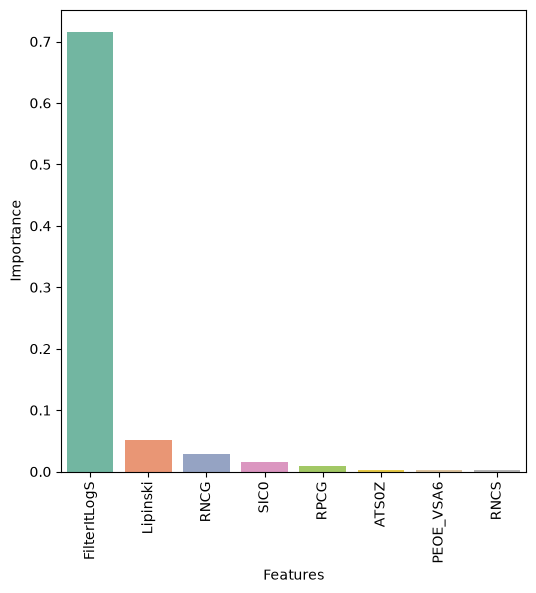

In [7]:
import seaborn  as sns 
importance = rf.feature_importances_
# summarize feature importance
dicts = {
    'Features':[x for x in df_final.iloc[:,3:].columns],
    'Importance':importance
    }
DF_imp = pd.DataFrame(dicts)
DF_imp = DF_imp.sort_values('Importance',ascending=False)
DF_imp.to_excel('imp.xlsx', index=None)

top_desc_fi = DF_imp[:8]
plt.subplots(figsize=(6,6))
sns.barplot(data=top_desc_fi, x = 'Features', y='Importance', palette = 'Set2')

plt.xticks(rotation = 90)
plt.show()


In [8]:
print(top_desc_fi.values)


[['FilterItLogS' 0.7161983965679224]
 ['Lipinski' 0.05193765495540378]
 ['RNCG' 0.028920349245491566]
 ['SIC0' 0.015926039713929366]
 ['RPCG' 0.0095207826191939]
 ['ATS0Z' 0.003335807148587512]
 ['PEOE_VSA6' 0.003208546111557596]
 ['RNCS' 0.0028270428078552693]]


In [9]:
df_final_8 = df_final[top_desc_fi['Features'].values[:8]]

df_final_8


,FilterItLogS,Lipinski,RNCG,SIC0,RPCG,ATS0Z,PEOE_VSA6,RNCS
0,-2.790326,1,0.330754,0.500000,0.551252,1230,34.802820,183.478709
1,-2.129911,1,0.311690,0.520426,0.695189,942,34.802820,196.813416
2,-2.433986,1,0.250000,0.500000,0.335426,1230,0.000000,244.111041
3,-2.147371,1,0.372917,0.520426,0.364050,942,0.000000,178.628094
4,-2.664600,1,0.277752,0.520426,0.533222,1182,23.201880,123.638050
...,...,...,...,...,...,...,...,...
1139,-2.002619,1,0.208329,0.369507,0.225705,1348,0.000000,10.782069
1140,-3.677096,1,0.283208,0.390072,0.279375,1260,29.780815,51.879710
1141,-4.965356,1,0.252199,0.259156,0.170939,956,42.464569,58.175506
1142,-4.497400,1,0.235956,0.362121,0.136406,1454,29.800041,65.022561


In [10]:
df_new = pd.concat([df_final_8 , y]  ,  axis  =1)

df_new.to_csv( 'delaney_8_des.csv', index = None)

In [11]:
y = df_final['measured log(solubility:mol/L)']
X = pd.DataFrame(StandardScaler().fit_transform(df_final_8), columns = df_final_8.columns)


In [12]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
print(f'The r2 score for train set is : {rf.score(X_train, y_train)}')
print(f'The r2 score for test set is : {rf.score(X_test, y_test)}')

The r2 score for train set is : 0.9815144932128852
The r2 score for test set is : 0.8885173382266232


In [13]:

et = ExtraTreesRegressor()
et.fit(X_train, y_train)
print(f'The r2 score for train set is : {et.score(X_train, y_train)}')
print(f'The r2 score for test set is : {et.score(X_test, y_test)}')

The r2 score for train set is : 1.0
The r2 score for test set is : 0.8951774437428023


**Rgressor means we subset the dataset to many smalldata and the model predict the output by each sample and fainaly it evaluate the predictions by the test**

**Now we have to finf the best params of our models by the Gridsearch and the randomsearch**

In [15]:
from sklearn.model_selection import GridSearchCV  , RandomizedSearchCV
rf = RandomForestRegressor(n_estimators=100,
                           bootstrap=True,# used the draw and sampling with replacement
                           max_depth=None,
                           max_features=1.0,
                           min_samples_leaf=1,
                           min_samples_split=2,
                          )
clf_rf = GridSearchCV(estimator=rf, param_grid = { 'n_estimators': [400, 600, 700, 800, 900],
                                                  'bootstrap': [True, False],
                                                  'max_depth': [30, 45, 60, 75, 100, None],
                                                  'max_features': ['log2', 'sqrt'],
                                                  'min_samples_leaf': [2, 4],
                                                  'min_samples_split': [5, 10],
                                                  }, cv=3, verbose=0, scoring='r2')

clf_rf.fit(X_train, y_train)

print(f'The r2 score for train set is : {clf_rf.score(X_train, y_train)}')
print(f'The r2 score for test set is : {clf_rf.score(X_test, y_test)}')

KeyboardInterrupt: 

In [ ]:

clf_rf.cv_results_
clf_rf_df = pd.DataFrame(clf_rf.cv_results_).sort_values('mean_test_score' , ascending= False).head()


In [ ]:
et = ExtraTreesRegressor(
                               n_estimators=100 , 
                               bootstrap=True,# used the draw and sampling with replacement
                               max_depth=None,
                               max_features=1.0,
                               min_samples_leaf=1,
                               min_samples_split=2,
                              
    
)

clr_et = GridSearchCV( estimator = et ,params_grid = {
                                                  'n_estimators': [400, 600, 700, 800, 900],
                                                  'bootstrap': [True, False],
                                                  'max_depth': [30, 45, 60, 75, 100, None],
                                                  'max_features': ['log2', 'sqrt'],
                                                  'min_samples_leaf': [2, 4],
                                                  'min_samples_split': [5, 10],
                                                  }, cv=3, verbose=0, scoring='r2')

clr_et.cv_results_
clf_et_df = pd.DataFrame(clf_rf.cv_results_).sort_values('mean_test_score' , ascending= False).head()
clr_et.best_params_
clr_et.fit(X_train , y_train)
print(f'The r2 score for train set is : {clr_et.score(X_train, y_train)}')
print(f'The r2 score for test set is : {clr_et.score(X_test, y_test)}')